In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
from dotenv import load_dotenv
import os

load_dotenv('.env')
mnist_train_fp = os.getenv('MNIST_TRAIN_FILEPATH')
mnist_test_fp = os.getenv('MNIST_TEST_FILEPATH')

print(f"Train dataset file path: {mnist_train_fp}")
print(f"Test dataset file path: {mnist_test_fp}")

Train dataset file: /home/ideras/classes/Redes_Neuronales/Datasets/mnist/numpy/mnist_train.npz
Test dataset file: /home/ideras/classes/Redes_Neuronales/Datasets/mnist/numpy/mnist_test.npz


In [5]:
mnist_train = np.load(mnist_train_fp)
mnist_test = np.load(mnist_test_fp)
train_images = mnist_train['images']
train_labels = mnist_train['labels']
test_images = mnist_test['images']
test_labels = mnist_test['labels']

X_train_full = train_images.reshape(train_images.shape[0], -1).astype('float32')
y_train_full = train_labels.astype('int')
X_test = test_images.reshape(test_images.shape[0], -1).astype('float32')
y_test = test_labels.astype('int')

print(f"Train dataset shape: {X_train_full.shape} : {y_train_full.shape}")
print(f"Test dataset shape: {X_test.shape} : {y_test.shape}")

Train dataset shape: (60000, 784) : (60000,)
Test dataset shape: (10000, 784) : (10000,)


In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

X_train_scaled = X_train / 255.0
X_val_scaled = X_val / 255.0
X_test_scaled = X_test / 255.0

In [16]:
X_train_scaled_tensor = torch.from_numpy(X_train_scaled).float()
X_val_scaled_tensor = torch.from_numpy(X_val_scaled).float()
X_test_scaled_tensor = torch.from_numpy(X_test_scaled).float()

y_train_tensor = torch.from_numpy(y_train).long()
y_val_tensor = torch.from_numpy(y_val).long()
y_test_tensor = torch.from_numpy(y_test).long()

In [17]:
train_dataset = TensorDataset(X_train_scaled_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_scaled_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [18]:
class MnistModel(nn.Module):
    def __init__(self):
        super(MnistModel, self).__init__()
        self.layer1 = nn.Linear(784, 128)
        self.layer2 = nn.Linear(128, 10)

    def forward(self, x):
        output = F.relu(self.layer1(x))
        output = self.layer2(output)
        return output

In [19]:
model = MnistModel()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
import time

epoch_count = 10

train_loss_history: list[float] = []
val_loss_history: list[float] = []

start_time = time.perf_counter()
for epoch in range(epoch_count):
    model.train()

    train_running_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = loss_function(preds, y_batch)

        loss.backward()
        optimizer.step()
        train_running_loss += loss.item()

    val_running_loss = 0.0
    model.eval()
    for x_batch, y_batch in val_loader:
        with torch.no_grad():
            preds = model(x_batch)
            loss = loss_function(preds, y_batch)
            val_running_loss += loss.item()

    train_epoch_loss = train_running_loss / len(train_loader)
    val_epoch_loss = val_running_loss / len(val_loader)
    train_loss_history.append(train_epoch_loss)
    val_loss_history.append(val_epoch_loss)
    print(f"Epoch: {epoch+1}. Train Loss: {train_epoch_loss:.4f}, Eval Loss: {val_epoch_loss:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.8f} seconds")

Epoch: 1. Train Loss: 0.3270, Eval Loss: 0.1866
Epoch: 2. Train Loss: 0.1473, Eval Loss: 0.1357
Epoch: 3. Train Loss: 0.1015, Eval Loss: 0.1202
Epoch: 4. Train Loss: 0.0754, Eval Loss: 0.1006
Epoch: 5. Train Loss: 0.0590, Eval Loss: 0.0936
Epoch: 6. Train Loss: 0.0459, Eval Loss: 0.0934
Epoch: 7. Train Loss: 0.0363, Eval Loss: 0.0934
Epoch: 8. Train Loss: 0.0292, Eval Loss: 0.0919
Epoch: 9. Train Loss: 0.0229, Eval Loss: 0.0908
Epoch: 10. Train Loss: 0.0205, Eval Loss: 0.0984
Execution time: 18.68314299 seconds


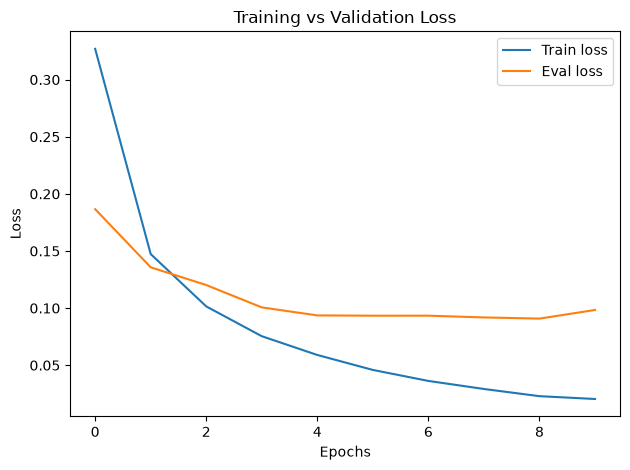

In [21]:
import matplotlib.pyplot as plt

epochs = [x for x in range(epoch_count)]
plt.plot(epochs, train_loss_history, label="Train loss")
plt.plot(epochs, val_loss_history, label="Eval loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
with torch.no_grad():
    model.eval()
    preds = model(X_test_scaled_tensor)
    loss = loss_function(preds, y_test_tensor).item()

    predicted_classes = torch.argmax(preds, dim=1)   # shape (batch_size,)
    accuracy = (predicted_classes == y_test_tensor).float().mean().item()

print(f"Loss of the model: {loss:.4f}")
print(f"Accuracy of the model: {accuracy:.4f}")

Loss of the model: 0.0918
Accuracy of the model: 0.9759
